# collect test gene ids

In [ ]:
# collected using codes main_lf_bag and model_lf_bag

In [4]:
file_path = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_df_ppi_pred/ICD10_J80_pred.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

In [3]:
data.keys()

dict_keys(['true_label', 'uniport_ppi_2019', 'ppi_2019_dw_40', 'diffusion_2019', 'uniport_bio', 'uniport_seq', 'uniport_esm', 'linear_fused', 'geo_fused'])

In [5]:
data.keys()

dict_keys(['true_label', 'uniport_ppi_2019', 'ppi_2019_dw_40', 'diffusion_2019', 'linear_fused', 'geo_fused'])

In [6]:
import os
import pickle

In [7]:
root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_lf_bag_cv_pred'
df_root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_df_pred'
df_ppi_root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_df_ppi_pred'
for file_name in os.listdir(root):
    file_path = os.path.join(root,file_name)
    disease_record = dict()
    with open(file_path, "rb") as f:
        base_data = pickle.load(f)
    with open(os.path.join(df_root,file_name), "rb") as f:
        df_data = pickle.load(f)
    with open(os.path.join(df_ppi_root,file_name), "rb") as f:
        df_ppi_data = pickle.load(f)
    df_data['train_pos_genes'] = base_data['train_pos_genes']
    df_data['test_genes'] = base_data['test_genes']
    df_data['geo_fused_ppi'] = df_ppi_data['geo_fused']
    df_data['linear_fused_ppi'] = df_ppi_data['linear_fused']
    with open(os.path.join(df_root, file_name), "wb") as f:
        pickle.dump(df_data, f)


# pathway overlap curves

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import gseapy as gp

In [8]:
with open('/itf-fi-ml/shared/users/ziyuzh/svm/data/uniport_id/uni2name.pkl', 'rb') as file:
    uni2name_dict = pickle.load(file)
def enriched_set(input_ids,time):
    gene_names = set()
    for unid in input_ids:
        gene_list = uni2name_dict.get(unid, [])
        gene_names.update(gene_list)
    gene_names = list(gene_names) 
    
    if time == 2019:
        enrich_db = ['GO_Biological_Process_2021','GO_Cellular_Component_2021','GO_Molecular_Function_2021','KEGG_2019_Human','Reactome_2022']
    elif time == 2017:
        enrich_db = ['GO_Biological_Process_2021','GO_Cellular_Component_2021','GO_Molecular_Function_2021','KEGG_2016']
    try:
        enr = gp.enrichr(
            gene_list=gene_names,
            gene_sets=enrich_db,
            organism='human', 
            outdir=None
        )
        enr_df = enr.results
        if enr_df is None or enr_df.empty:
            return set()
        
        result_terms = enr_df.loc[enr_df['Adjusted P-value'] < 0.01, ['Gene_set', 'Term']]
        return set(map(tuple, result_terms.values))
    
    except Exception as e:
        # Optionally log the error: print(f"Enrichment failed: {e}")
        return set()

def calculate_jac_sim(enrich_1, enrich_2):
    intersection = enrich_1 & enrich_2
    union = enrich_1 | enrich_2
    if not union:
        return 0.0  # Define similarity as 0 if both sets are empty
    return len(intersection) / len(union)

In [ ]:
root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_lf_bag_cv_pred'
for file_name in os.listdir(root):
    file_path = os.path.join(root,file_name)
    disease_record = dict()
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    train_genes = data['train_pos_genes']
    enrich_train_set = enriched_set(train_genes,2019)
    test_indices = data['test_genes']
    for feature in ['uniport_ppi_2019', 'ppi_2019_dw_40', 'diffusion_2019', 'uniport_bio', 'uniport_seq', 'uniport_esm']:
        final_y_score = data[feature]
        sim_scores = []
        for ratio in np.linspace(0, 0.5, 10):
            enrich_predict_genes = test_indices[np.argsort(final_y_score)[::-1]][:int(ratio*len(final_y_score))]
            enrich_predict_set = enriched_set(enrich_predict_genes,2019)
            jac_sm0 = calculate_jac_sim(enrich_train_set,enrich_predict_set)
            sim_scores.append(jac_sm0)
    disease_record[feature] = sim_scores    
    break

KeyboardInterrupt: 

In [14]:
disease_record.keys()

dict_keys(['uniport_ppi_2019', 'ppi_2019_dw_40', 'diffusion_2019', 'uniport_bio', 'uniport_seq', 'uniport_esm', 'later_fused_ppi', 'later_fused_all', 'later_fused_bag_1_ppi', 'later_fused_bag_1_all', 'later_fused_bag_2_all', 'later_fused_bag_2_ppi'])

In [36]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import Iterable, Optional, Tuple
import seaborn as sns


def plot_aggregated_features(
    root: str,
    selected_features: Iterable[str],
    colors,
    x: Optional[np.ndarray] = None,
    ci_z: float = 1.96,           # 95% CI
    legend_outside: bool = True,
    show: bool = True,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot mean curves across all disease files for the given features, with 95% CI bands.

    Parameters
    ----------
    root : str
        Directory containing pickled disease records (dict: feature -> sequence of y).
    selected_features : Iterable[str]
        Features to include.
    x : np.ndarray, optional
        X-axis values. If None, defaults to np.linspace(0, 0.5, 10).
    ci_z : float
        Z-value for confidence band (1.96 ~ 95% CI).
    legend_outside : bool
        If True, place legend outside to the right.
    show : bool
        If True, call plt.show().

    Returns
    -------
    (fig, ax) : tuple
        Matplotlib figure and axes objects.
    """
    if x is None:
        x = np.linspace(0, 0.5, 10)

    selected_features = list(selected_features)
    feature_to_curves = defaultdict(list)

    # Load and collect curves
    for file_name in os.listdir(root):
        file_path = os.path.join(root, file_name)
        if not os.path.isfile(file_path):
            continue
        with open(file_path, "rb") as f:
            disease_record = pickle.load(f)

        for feature, values in disease_record.items():
            if feature in selected_features:
                y = np.asarray(values, dtype=float)
                if y.size != x.size:
                    raise ValueError(
                        f"In file '{file_name}', feature '{feature}' has length {y.size}, "
                        f"expected {x.size} to match x."
                    )
                feature_to_curves[feature].append(y)

    fig, ax = plt.subplots(figsize=(7, 4.5))

    # Use seaborn colorblind palette
    palette = sns.color_palette(colors, n_colors=len(feature_to_curves))

    # Plot per feature
    for i, (feature, curves) in enumerate(feature_to_curves.items()):
        arr = np.vstack(curves)              # shape: (num_diseases, len(x))
        n = arr.shape[0]
        mean = arr.mean(axis=0)
        std = arr.std(axis=0, ddof=1 if n > 1 else 0)
        se = std / np.sqrt(n) if n > 0 else std
        band = ci_z * se                     # 95% CI by default

        color = palette[i]
        ax.plot(x, mean, label=feature, linewidth=2, color=color)
        ax.fill_between(x, mean - band, mean + band, alpha=0.2, color=color, linewidth=0)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Across-Disease Mean Curves with 95% Confidence Bands")
    ax.grid(True, alpha=0.3)

    if legend_outside:
        ax.legend(title="feature", loc="center left", bbox_to_anchor=(1, 0.5))
        fig.tight_layout()
    else:
        ax.legend(title="feature")
        fig.tight_layout()

    if show:
        plt.show()

    return fig, ax


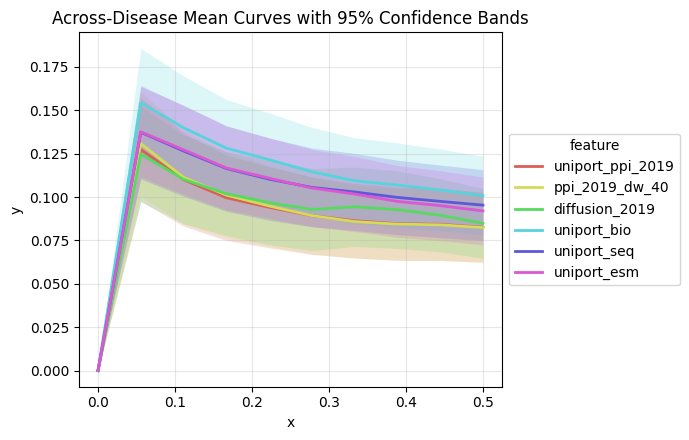

In [47]:
# Define your data directory and features of interest
root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_lf_bag_cv_pred_sim'
selected_features = [
    'uniport_ppi_2019', 'ppi_2019_dw_40', 'diffusion_2019',
    'uniport_bio', 'uniport_seq', 'uniport_esm'
]

# Call the function
fig, ax = plot_aggregated_features(
    root=root,
    selected_features=selected_features,
    colors='hls',
    ci_z=1.96,             # 95% CI
    legend_outside=True,   # put legend outside the plot
    show=True              # display with plt.show()
)


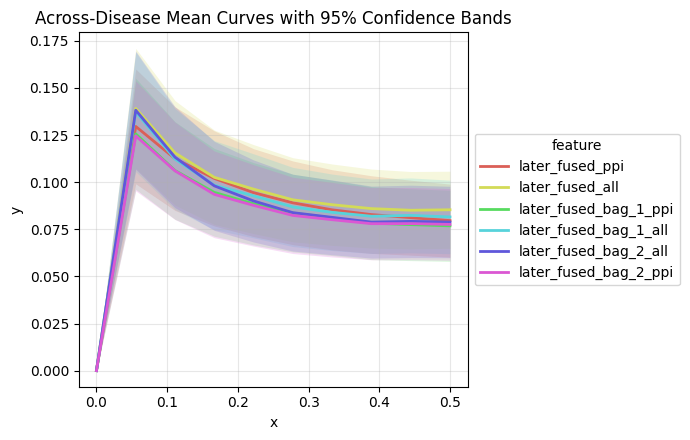

In [48]:
selected_features = ['later_fused_ppi', 'later_fused_all', 'later_fused_bag_1_ppi', 'later_fused_bag_1_all', 'later_fused_bag_2_all', 'later_fused_bag_2_ppi']
# Call the function
fig, ax = plot_aggregated_features(
    root=root,
    selected_features=selected_features,
    colors='hls',
    ci_z=1.96,             # 95% CI
    legend_outside=True,   # put legend outside the plot
    show=True              # display with plt.show()
)

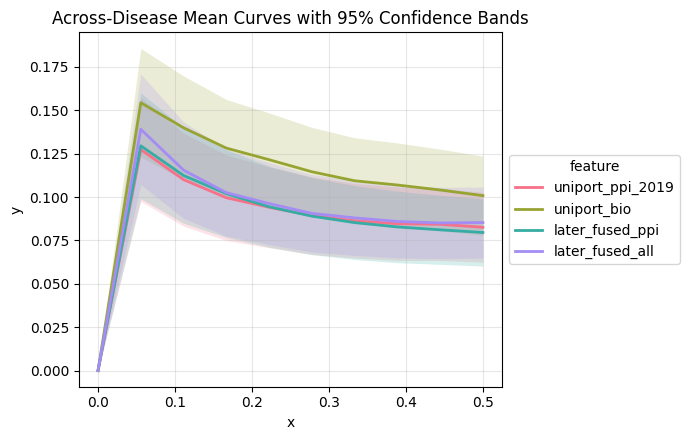

In [49]:
selected_features = [
        'uniport_ppi_2019', 
    'uniport_bio', 
'later_fused_ppi', 'later_fused_all']

fig, ax = plot_aggregated_features(
    root=root,
    selected_features=selected_features,
    colors='husl',
    ci_z=1.96,             # 95% CI
    legend_outside=True,   # put legend outside the plot
    show=True              # display with plt.show()
)

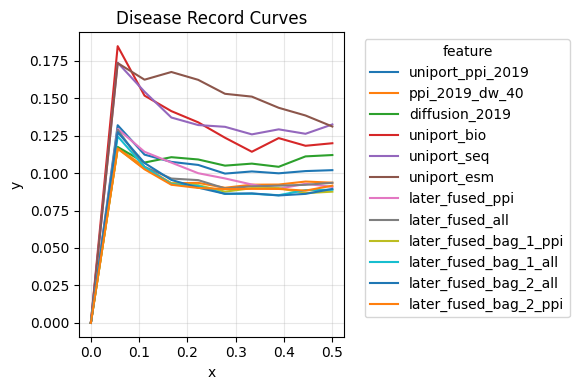

In [45]:
import matplotlib.pyplot as plt
import os, pickle
import numpy as np

disease_code = 'C16'

file_path = os.path.join(root, 'ICD10_'+disease_code+'_pred.pkl')
with open(file_path, "rb") as f:
    disease_record = pickle.load(f)

# x-axis
x = np.linspace(0, 0.5, 10)  # use endpoint=False if you don't want 0.5 included

plt.figure(figsize=(6,4))

for feature, values in disease_record.items():
    y = np.asarray(values)
    if y.size != x.size:
        raise ValueError(f"Feature '{feature}' has length {y.size}, expected {x.size} to match x.")
    plt.plot(x, y, label=feature)  # colors auto-cycled

plt.xlabel("x")
plt.ylabel("y")
plt.title("Disease Record Curves")

# Move legend outside (right side)
plt.legend(title="feature", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# external validation (OT 2019)

In [ ]:
'/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/ot_dgas.csv'
'/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/2019/row_dga_2019.csv'

In [1]:
import pandas as pd

In [7]:
ot_dgas = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/ot_dga_newest.csv')
# ot_dgas = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/ot_external_19_25.csv')
len(ot_dgas)

388643

In [3]:
# ot_dgas = ot_dgas[ot_dgas['uniport'].isin(all_test_genes)]
# len(ot_dgas)

In [4]:
ot_dgas['disease_id'].value_counts()

disease_id
ICD10_C50    12964
ICD10_C18    10448
ICD10_C43     9740
ICD10_G30     6629
ICD10_E11     5990
ICD10_C53     5836
ICD10_G20     4598
ICD10_K51     4361
ICD10_G10     4053
ICD10_N18     4046
ICD10_I10     3495
ICD10_F20     3371
ICD10_I70     3211
ICD10_N46     2795
ICD10_G40     2753
ICD10_C81     2546
ICD10_J80     2516
ICD10_L40     2238
ICD10_M34     2174
ICD10_N80     1939
ICD10_F31     1744
ICD10_I42     1699
ICD10_N04     1531
ICD10_D57     1461
ICD10_J45     1356
ICD10_C67     1348
ICD10_C23     1182
ICD10_I63     1138
ICD10_D83      817
ICD10_M32      786
ICD10_F01      765
ICD10_J62      749
ICD10_E66      496
ICD10_M41      492
ICD10_G24      444
ICD10_K44      348
ICD10_G91      319
ICD10_I26      226
ICD10_I50      182
ICD10_N17      103
ICD10_N97      101
ICD10_G43       90
ICD10_C16       72
ICD10_I25       54
ICD10_F72        8
Name: count, dtype: int64

In [5]:
ot_dgas[ot_dgas['score']>=0.35]['disease_id'].value_counts()

disease_id
ICD10_C43    360
ICD10_I10    308
ICD10_E11    298
ICD10_G20    230
ICD10_C50    196
ICD10_G30    160
ICD10_C18    149
ICD10_J45    106
ICD10_C67     83
ICD10_C81     76
ICD10_F20     38
ICD10_F31     38
ICD10_C53     33
ICD10_N46     31
ICD10_E66     29
ICD10_G40     25
ICD10_J80     24
ICD10_N04     24
ICD10_K51     22
ICD10_L40     19
ICD10_I42     16
ICD10_C23     16
ICD10_M32     16
ICD10_N80     16
ICD10_N18     13
ICD10_M41      9
ICD10_I26      8
ICD10_G91      6
ICD10_F01      5
ICD10_I50      4
ICD10_I70      2
ICD10_G24      2
ICD10_F72      1
ICD10_K44      1
ICD10_D83      1
ICD10_M34      1
Name: count, dtype: int64

In [6]:
from model_lf_bag import eval_bagging
import os
import numpy as np
import pickle

In [8]:
root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_lf_bag_cv_all_save_pred'
# out_path = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_lf_bag_cv_external_35'
out_path = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_lf_bag_cv_all_save_pred_temp'

# root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_df_pred'
# out_path = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_df_pred_external_35'
dgs_score_cut = 0

# dgs_score_cut = 0.35
# all_test_genes = set()
# disease_dict = dict()
# disease_dict['disease'] = []
# disease_dict['external_test_pos_num'] = []

os.makedirs(out_path, exist_ok=True)
ot_dgas = ot_dgas[ot_dgas['score']>=dgs_score_cut]
for file_name in os.listdir(root):
    disease = '_'.join(file_name.split('_')[:2])
    if disease not in ot_dgas['disease_id'].unique().tolist():
        print(disease, ' not external info')
    # else:
    if disease == 'ICD10_J80':
        result_df = pd.DataFrame(columns=['method',"fold","para", 'top_recall_25','top_recall_300','top_recall_10%', 'top_precision_10%', 'max_precision_10%','top_recall_30%', 'top_precision_30%', 'max_precision_30%','pm_0.5%','pm_1%','pm_5%','pm_10%','pm_15%','pm_20%','pm_25%','pm_30%','auroc',"rank_ratio",'bedroc_1','bedroc_5','bedroc_10','bedroc_30'])
        file_path = os.path.join(root,file_name)
        with open(file_path, "rb") as f:
            data = pickle.load(f)
        train_genes = data['train_pos_genes']
        test_genes = data['test_genes']
        # all_test_genes.update(set(test_genes))
        disease_dgas = ot_dgas[ot_dgas['disease_id']==disease]

        disease_set = set(disease_dgas['uniport'].dropna())

        y_test = np.array([1 if uid in disease_set else 0 for uid in test_genes])

        # disease_dict['disease'].append(disease)
        # disease_dict['external_test_pos_num'].append(y_test.sum())

        # # break
        for feature in data.keys():
            if feature not in ['train_pos_genes','test_genes','true_label']:
                final_y_score = data[feature]
                ranked_predict_index, results = eval_bagging(final_y_score, y_test)
                jac_sm0 = 0
                jac_sm1 = 0
                jac_sm2 = 0
                result_df.loc[len(result_df.index)] = ["random_negative",0,feature+'-'+str(round(jac_sm0, 3))+'-'+str(round(jac_sm1, 3))+'-'+str(round(jac_sm2, 3)), *results]
        result_df.to_csv(os.path.join(out_path, f"{disease}.csv"),index = False)
        print(disease, ' external saved')
        break

ICD10_D66  not external info
ICD10_J80  external saved


In [19]:
from rdkit.ML.Scoring.Scoring import CalcBEDROC
scores = np.column_stack((y_test, final_y_score))  # Stack labels and scores as columns
scores = scores[scores[:, 1].argsort()[::-1]] 
CalcBEDROC(scores, col=0, alpha=160.9),CalcBEDROC(scores, col=0, alpha=32.2)

(0.8789876402173487, 0.6725297151634029)

In [20]:
pos_loc = np.where(scores[:, 0] == 1)[0]

In [73]:
(len(pos_loc)/len(y_test))*alpha

23.556130476495046

In [42]:
import math
def _RIEHelper(scores, col, alpha):
  numMol = len(scores)
  alpha = float(alpha)
  if numMol == 0:
    raise ValueError('score list is empty')
  if alpha <= 0.0:
    raise ValueError('alpha must be greater than zero')

  denom = 1.0 / numMol * ((1 - math.exp(-alpha)) / (math.exp(alpha / numMol) - 1))
  numActives = 0
  sum_exp = 0

  # loop over score list
  for i in range(numMol):
    active = scores[i][col]
    if active:
      numActives += 1
      sum_exp += math.exp(-(alpha * (i + 1)) / numMol)

  if numActives > 0:  # check that there are actives
    RIE = sum_exp / (numActives * denom)
  else:
    RIE = 0.0

  return RIE, numActives

def CalcBEDROC(scores, col, alpha):
  """ BEDROC original defined here:
    Truchon, J. & Bayly, C.I.
    Evaluating Virtual Screening Methods: Good and Bad Metric for the "Early Recognition"
    Problem. J. Chem. Inf. Model. 47, 488-508 (2007).
    ** Arguments**

      - scores: 2d list or numpy array
             0th index representing sample
             scores must be in sorted order with low indexes "better"
             scores[sample_id] = vector of sample data
      -  col: int
             Index of sample data which reflects true label of a sample
             scores[sample_id][col] = True iff that sample is active
      -  alpha: float
             hyper parameter from the initial paper for how much to enrich the top
     **Returns**
       float BedROC score
    """
  # calculate RIE
  RIE, numActives = _RIEHelper(scores, col, alpha)

  if numActives > 0:
    numMol = len(scores)
    ratio = 1.0 * numActives / numMol
    RIEmax = (1 - math.exp(-alpha * ratio)) / (ratio * (1 - math.exp(-alpha)))
    RIEmin = (1 - math.exp(alpha * ratio)) / (ratio * (1 - math.exp(alpha)))

    if RIEmax != RIEmin:
      BEDROC = (RIE - RIEmin) / (RIEmax - RIEmin)
    else:  # numActives = numMol
      BEDROC = 1.0
  else:
    BEDROC = 0.0

  return BEDROC

CalcBEDROC(scores, col=0, alpha=160.9)

0.8789876402173487

(array([830., 403., 259., 219., 136., 113.,  83.,  92.,  79.,  75.]),
 array([    0. ,  1558.8,  3117.6,  4676.4,  6235.2,  7794. ,  9352.8,
        10911.6, 12470.4, 14029.2, 15588. ]),
 <BarContainer object of 10 artists>)

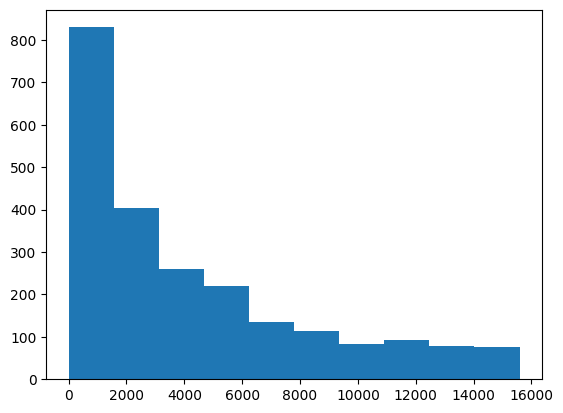

In [16]:
import matplotlib.pyplot as plt
plt.hist(pos_loc)

First 10 predictions: [0 0 0 0 0 0 0 0 0 0]
AUC-ROC: 0.7713


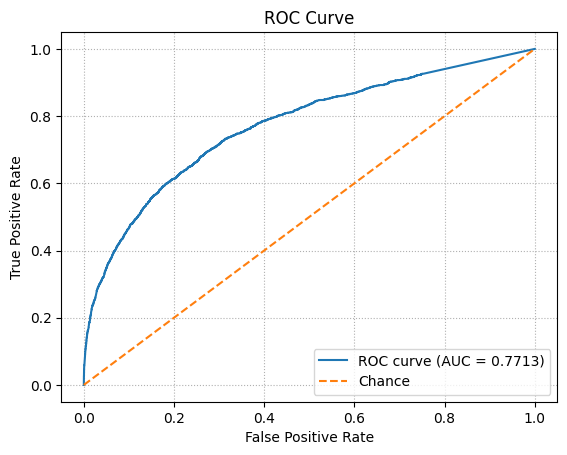

In [21]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- inputs (you already have these) ---
# y_test: shape (n,), values in {0,1}
# final_y_score: shape (n,) with positive-class scores, or shape (n,2) with class probs

# Ensure we use the positive-class score
y_true = np.asarray(y_test).astype(int)
y_score = np.asarray(final_y_score)
if y_score.ndim == 2:  # e.g., probabilities for [neg, pos]
    y_score = y_score[:, 1]

# 1) Binary prediction at threshold 0.5 (adjust threshold if you wish)
y_pred = (y_score >= 0.5).astype(int)
print("First 10 predictions:", y_pred[:10])

# 2) ROC + AUC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
print(f"AUC-ROC: {roc_auc:.4f}")

# 3) Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":")
plt.show()


In [ ]:
## BEDROC by hand
scores = np.column_stack((y_test, final_y_score))  # Stack labels and scores as columns
scores = scores[scores[:, 1].argsort()[::-1]] 
pos_loc = np.where(scores[:, 0] == 1)[0] + 1

In [26]:
n = len(pos_loc)
N = len(y_test)
alpha = 160.9

p = pos_loc / N

numerator = np.mean(np.exp(-alpha * p))
C = (alpha / N) * ((1.0 - np.exp(-alpha)) / (np.exp(alpha / N) - 1.0))

bedroc = numerator / C + 1.0 / (1.0 - np.exp(alpha))
bedroc

0.03770059006916748

In [33]:
numerator, C, numerator / C

(0.037506934146468045, 0.9948633185224914, 0.03770059006916748)

In [ ]:
scores = np.column_stack((y_test, final_y_score))  # Stack labels and scores as columns
scores = scores[scores[:, 1].argsort()[::-1]] 
pos_loc = np.where(scores[:, 0] == 1)[0] + 1

n = len(pos_loc)
N = len(y_test)
alpha = 160.9

rie_nu = np.mean(np.exp(-alpha * (pos_loc / N)))
rie_de = 1/N * ((1-np.exp(-alpha))/(np.exp(alpha/N)-1))
rie = rie_nu/rie_de

rie_min = alpha/(np.exp(alpha)-1)
rie_max = alpha/ (1-np.exp(-alpha))

bedroc = (rie - rie_min) / (rie_max - rie_min)
bedroc

0.037700590069167476

In [72]:

scores = np.column_stack((y_test, final_y_score))  # Stack labels and scores as columns
scores = scores[scores[:, 1].argsort()[::-1]] 
pos_loc = np.where(scores[:, 0] == 1)[0] + 1

n = len(pos_loc)
N = len(y_test)
alpha = 160.9
ratio = n/N

rie_nu = np.mean(np.exp(-alpha * (pos_loc / N)))
rie_de = 1/N * ((1-np.exp(-alpha))/(np.exp(alpha/N)-1))
rie = rie_nu/rie_de

RIEmax = (1 - math.exp(-alpha * ratio)) / (ratio * (1 - math.exp(-alpha)))
RIEmin = (1 - math.exp(alpha * ratio)) / (ratio * (1 - math.exp(alpha)))

bedroc = (rie - RIEmin) / (RIEmax - RIEmin)
bedroc,rie,RIEmax,RIEmin,(rie - RIEmin) , (RIEmax - RIEmin),rie_nu,rie_de


(0.8789876402173508,
 6.0039195080775825,
 6.830493664954116,
 1.5373311799698475e-59,
 6.0039195080775825,
 6.830493664954116,
 0.037122929061205644,
 0.006183115714869431)

In [71]:
scores = np.column_stack((y_test, final_y_score))  # Stack labels and scores as columns
scores = scores[scores[:, 1].argsort()[::-1]] 
pos_loc = np.where(scores[:, 0] == 1)[0] + 1

n = len(pos_loc)
N = len(y_test)
alpha = 32.2
ratio = n/N

rie_nu = np.mean(np.exp(-alpha * (pos_loc / N)))
rie_de = 1/N * ((1-np.exp(-alpha))/(np.exp(alpha/N)-1))
rie = rie_nu/rie_de

RIEmax = (1 - math.exp(-alpha * ratio)) / (ratio * (1 - math.exp(-alpha)))
RIEmin = (1 - math.exp(alpha * ratio)) / (ratio * (1 - math.exp(alpha)))

bedroc = (rie - RIEmin) / (RIEmax - RIEmin)
bedroc,rie,RIEmax,RIEmin,(rie - RIEmin) , (RIEmax - RIEmin),rie_nu,rie_de


(0.6725297151634043,
 4.5525161037590545,
 6.769241568233707,
 7.826882711546448e-12,
 4.552516103751228,
 6.769241568225881,
 0.14123695032737152,
 0.031023932064897224)

In [68]:
#### random
def bedroc_ranmdom(n, N, alpha):
    bedroc_all = []
    for i in range(1000):
        y_true = np.zeros(N, dtype=int)
        y_true[:n] = 1
        np.random.shuffle(y_true)
        pos_loc = np.where(y_true == 1)[0] + 1

        ratio = n/N

        rie_nu = np.mean(np.exp(-alpha * (pos_loc / N)))
        rie_de = 1/N * ((1-np.exp(-alpha))/(np.exp(alpha/N)-1))
        rie = rie_nu/rie_de

        RIEmax = (1 - math.exp(-alpha * ratio)) / (ratio * (1 - math.exp(-alpha)))
        RIEmin = (1 - math.exp(alpha * ratio)) / (ratio * (1 - math.exp(alpha)))

        bedroc = (rie - RIEmin) / (RIEmax - RIEmin)
        bedroc_all.append(bedroc)
    return sum(bedroc_all)/len(bedroc_all)

alpha = 160.9
N = 15000
bedroc_ranmdom(2, N, alpha), bedroc_ranmdom(20, N, alpha),bedroc_ranmdom(200, N, alpha),bedroc_ranmdom(2000, N, alpha)

(0.0067681413735948175,
 0.007431721752723696,
 0.014657183911409966,
 0.13325518429612504)

In [ ]:
# df = pd.DataFrame.from_dict(disease_dict)
# df.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_external_summary.csv',index=False)

In [31]:
disease_dgas

,score,disease_id,uniport
203,0.532395,ICD10_F31,P07332
369,0.496072,ICD10_F31,Q7Z3B1
382,0.492907,ICD10_F31,P08949
410,0.485956,ICD10_F31,Q9UPZ6
460,0.477333,ICD10_F31,Q9C0K0
524,0.466284,ICD10_F31,O60443
649,0.459004,ICD10_F31,P43146
702,0.452505,ICD10_F31,Q9UPU3
711,0.451762,ICD10_F31,Q92481
844,0.439466,ICD10_F31,P25942
